#Forward Propagation

## Import libraries



In [56]:
!pip install numpy matplotlib scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

## Define activation functions


In [57]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def softmax(z):
    # Numerically stable softmax
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


## Load & Prepare Wine Dataset

Dataset properties:
- 178 samples
- 13 input features per sample
- 3 output classes

X - input features  
y - class labels

This dataset is used only to demonstrate how forward propagation works on real data.






In [58]:
wine = load_wine()

X = wine.data        # shape: (178, 13)
y = wine.target      # 3 classes: 0,1,2

print("Input shape:", X.shape)
print("Target shape:", y.shape)


Input shape: (178, 13)
Target shape: (178,)


### Standardize features

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train–Test Split



In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples     :", X_test.shape[0])


Training samples: 142
Test samples     : 36



## Neural Network Architecture



In [61]:
input_neurons = 13
hidden_neurons = 8
output_neurons = 3

print("Network Architecture")
print(f"Input  : {input_neurons}")
print(f"Hidden : {hidden_neurons}")
print(f"Output : {output_neurons}")


Network Architecture
Input  : 13
Hidden : 8
Output : 3


## Initialize weights and biases


In [62]:
# Initialize weights and biases
weights_input_hidden = np.random.randn(input_neurons, hidden_neurons)
biases_hidden = np.zeros((1, hidden_neurons))

weights_hidden_output = np.random.randn(hidden_neurons, output_neurons)
biases_output = np.zeros((1, output_neurons))

# Print shapes to verify
print("Shape of weights_input_hidden:", weights_input_hidden.shape)
print("Shape of biases_hidden:", biases_hidden.shape)
print("Shape of weights_hidden_output:", weights_hidden_output.shape)
print("Shape of biases_output:", biases_output.shape)

Shape of weights_input_hidden: (13, 8)
Shape of biases_hidden: (1, 8)
Shape of weights_hidden_output: (8, 3)
Shape of biases_output: (1, 3)


## Implement forward propagation

In [63]:
def forward_propagation(X, W1, b1, W2, b2):
    # Hidden layer
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)

    # Output layer
    z2 = np.dot(a1, W2) + b2
    a2 = softmax(z2)   # element-wise, for demo

    return z1, a1, z2, a2

## Run Forward Propogation on one wine sample

In [64]:
sample_index = 0
sample_input = X_train[sample_index].reshape(1, -1)

z1, a1, z2, output = forward_propagation(
    sample_input,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)

print("\nHidden Layer Output (Before ReLU):")
print(z1)

print("\nHidden Layer Output (After ReLU):")
print(a1)

print("\nOutput Layer (After Softmax):")
print(output)
print("Sum of probabilities:", np.sum(output))



Hidden Layer Output (Before ReLU):
[[ 3.84695631 -0.64817438 -4.5273434  -0.27074728  0.36691705 -0.44210664
  -0.77328058  0.9210116 ]]

Hidden Layer Output (After ReLU):
[[3.84695631 0.         0.         0.         0.36691705 0.
  0.         0.9210116 ]]

Output Layer (After Softmax):
[[0.81490565 0.13636346 0.04873089]]
Sum of probabilities: 1.0


In [65]:
predicted_class = np.argmax(output)
true_class = y_train[sample_index]

print("\nPredicted Class:", predicted_class)
print("True Class     :", true_class)


Predicted Class: 0
True Class     : 0


## Visualization: Actual vs Predicted Classes




In [66]:
num_samples = X_train.shape[0]
actual_classes = y_train

# Run forward propagation for all training samples to get predicted classes
_, _, _, probabilities = forward_propagation(
    X_train,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)
predicted_classes = np.argmax(probabilities, axis=1)

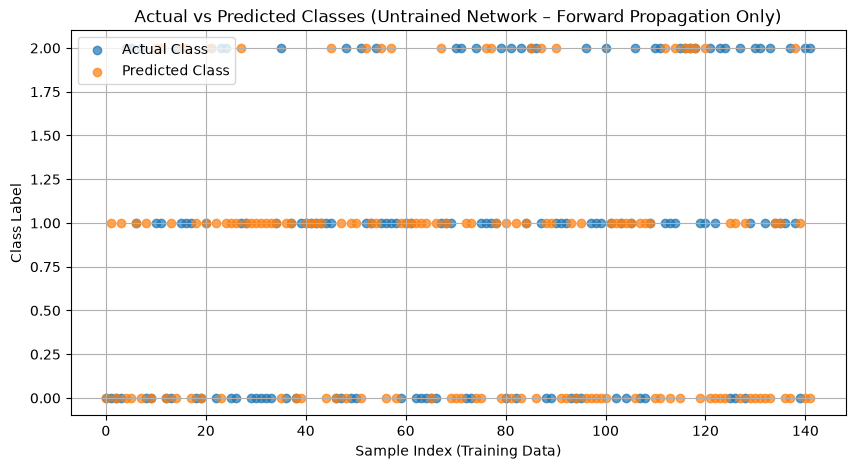

In [67]:
plt.figure(figsize=(10, 5))
plt.scatter(range(num_samples), actual_classes,label="Actual Class", alpha=0.7)
plt.scatter(range(num_samples), predicted_classes,label="Predicted Class", alpha=0.7)
plt.xlabel("Sample Index (Training Data)")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted Classes (Untrained Network – Forward Propagation Only)")
plt.legend()
plt.grid(True)

plt.show()

In [68]:
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train_one_hot = one_hot_encode(y_train, output_neurons)


In [69]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon , 1 - epsilon)
    loss = -np.sum(y_true * np.log(y_pred), axis=1)
    return np.mean(loss)

In [70]:
y_true_sample = y_train_one_hot[sample_index].reshape(1,-1)
y_pred_sample = output 
loss_sample = cross_entropy_loss(y_true_sample, y_pred_sample)
print("Loss for a single sample:", loss_sample)

Loss for a single sample: 0.2046829377864126


In [71]:
def backward_propogation(X, y_true, z1, a1, z2, a2, W2):
    m = X.shape[0]
    #output layer gradients
    dz2 = (a2 - y_true) / m 
    #calculating activation 1 with z2 
    dw2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis = 0, keepdims = True) 
    #Hidden layer gradients 
    da1 = np.dot(dz2, W2.T) 
    dz1 = da1.copy() 
    dz1[z1 <= 0] = 0 #derivative of Relu 

    dw1 = np.dot(X.T, dz1) 
    db1 = np.sum(dz1, axis = 0 , keepdims = True)

    return dw1, db1, dw2, db2



    
    

# Parameter Update(Gradient Descent)

In [72]:
def update_parameters(w1,b1,w2,b2,dw1,db1,dw2,db2,lr):
    w1 -= lr * dw1 
    b1 -= lr * db1
    w2 -= lr * dw2 
    b2 -= lr * db2 
    return w1, b1, w2, b2 


In [73]:
learning_rate = 0.05 
epochs = 100 
loss_history = []
for epoch in range(epochs):
    z1, a1, z2,a2 = forward_propagation(
        X_train,
        weights_input_hidden,
        biases_hidden,
        weights_hidden_output,
        biases_output
    )
    loss = cross_entropy_loss(y_train_one_hot, a2)
    loss_history.append(loss)
    #Backward Propogation 
    dw1, db1, dw2, db2 = backward_propogation(
        X_train, y_train_one_hot, 
        z1,a1,z2,a2,weights_hidden_output 
    )
    weights_input_hidden, biases_hidden, weights_hidden_output, biases_output = update_parameters(
    weights_input_hidden, biases_hidden,
    weights_hidden_output, biases_output, 
    dw1 ,db1, dw2, db2, learning_rate 
    )
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

    

Epoch 0, Loss: 4.4757
Epoch 20, Loss: 0.5371
Epoch 40, Loss: 0.2576
Epoch 60, Loss: 0.1563
Epoch 80, Loss: 0.1031


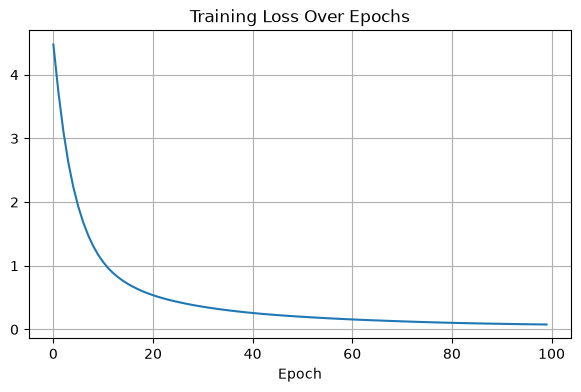

In [74]:
plt.figure(figsize = (7,4)) 
plt.plot(loss_history)
plt.xlabel("Epoch") 
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()


In [75]:
def predict(x1, w1, b1, w2, b2):
    _,_,_,a2 = forward_propagation(x1, w1, b1, w2, b2)
    return np.argmax(a2, axis = 1)

In [76]:
y_train_pred = predict(
    X_train,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)
y_test_pred = predict(
    X_test, 
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output

)
train_accuracy = np.mean(y_train_pred == y_train) 
test_accuracy = np.mean(y_test_pred == y_test) 
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy    : {test_accuracy * 100:.2f}%")

Training Accuracy: 97.18%
Test Accuracy    : 91.67%


In [77]:
y_test_one_hot = one_hot_encode(y_test, output_neurons) 

#Forward pass 
_,_,_,a2_train = forward_propagation(
    X_train,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)
_,_,_,a2_test = forward_propagation(
    X_test,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)
train_loss = cross_entropy_loss(y_train_one_hot, a2_train) 
test_loss = cross_entropy_loss(y_test_one_hot, a2_test)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss    : {test_loss:.4f}")

Training Loss: 0.0759
Test Loss    : 0.2803


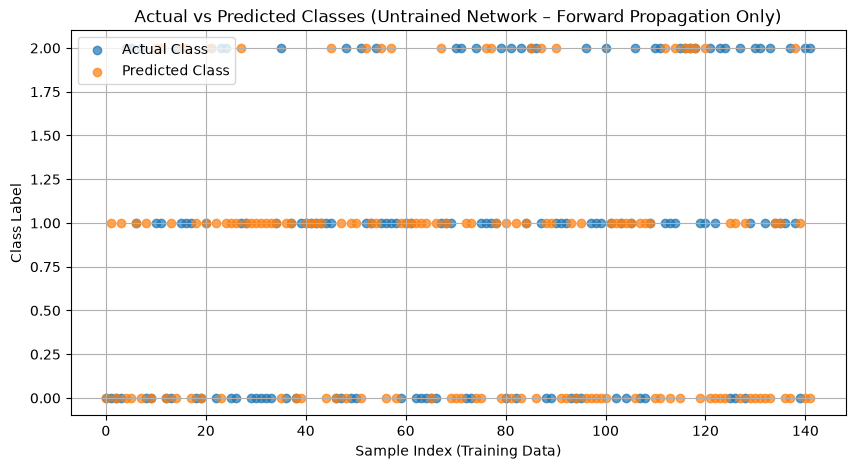

In [78]:
plt.figure(figsize=(10, 5))
plt.scatter(range(num_samples), actual_classes,label="Actual Class", alpha=0.7)
plt.scatter(range(num_samples), predicted_classes,label="Predicted Class", alpha=0.7)
plt.xlabel("Sample Index (Training Data)")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted Classes (Untrained Network – Forward Propagation Only)")
plt.legend()
plt.grid(True)

plt.show()